# CCP Margin Adequacy, Backtesting, and Risk Governance Engine

This notebook is a single end-to-end walkthrough of the project. It shows how the engine generates synthetic cleared portfolios, revalues them under historical and stressed conditions, computes liquidation-adjusted margin, and translates quantitative breaches into governance actions and committee-style reports.

## What this notebook covers

- the business question and architecture
- synthetic market data, instruments, member archetypes, and collateral
- pricing, historical and stressed scenarios, and margin decomposition
- adequacy controls, margin calls, backtesting, and data-quality checks
- escalation logic, reporting outputs, validation, and known limitations

## Presentation Framing

A concise way to describe the project in an interview or portfolio review:

> I built a stylised CCP risk platform that answers whether each clearing member's posted collateral is sufficient to survive liquidation-adjusted losses under historical and stressed conditions. The engine combines full revaluation, liquidity and concentration add-ons, backtesting, operational controls, rule-based escalation, and committee-ready reporting.

What makes this stronger than a plain VaR demo:

- margin is decomposed into baseline risk, liquidity cost, and concentration cost
- adequacy is operationalised with thresholds, traffic lights, and minimum transfer logic
- governance is explicit through backtesting, DQ checks, escalation ownership, and report generation
- the full workflow runs offline on synthetic but structured data, so the project is reproducible

In [1]:
from pathlib import Path
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import config
from src.backtesting import compute_exceptions, rolling_exception_count, run_all_data_quality_checks
from src.controls import compute_adequacy
from src.data_loader import load_processed, load_synthetic, table_exists
from src.escalation import generate_escalation_log
from src.margin import compute_all_margins
from src.portfolio import generate_all
from src.pricing import compute_daily_pnl, price_instrument
from src.reporting import (
    committee_pack_markdown,
    daily_risk_review,
    export_member_margin_adequacy,
    generate_breach_register,
    monthly_committee_pack,
)
from src.scenarios import historical_return_scenarios, stressed_return_scenarios

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
pd.options.display.float_format = "{:,.2f}".format

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid", context="talk")


## Optional Pipeline Refresh

The next cell will load all synthetic, processed, and reporting outputs. If any required tables are missing, it will run the full pipeline automatically. Set `REFRESH_PIPELINE = True` if you want to regenerate everything from scratch before presenting.

In [2]:
REFRESH_PIPELINE = False

required_synthetic = [
    "market_data",
    "instruments",
    "member_profiles",
    "positions",
    "collateral",
    "product_universe",
]
required_processed = [
    "pnl_history",
    "margin_results",
    "adequacy",
    "exceptions",
    "rolling_exceptions",
    "dq_flags",
    "escalation_log",
]

missing_synthetic = [name for name in required_synthetic if not table_exists(name, "synthetic")]
missing_processed = [name for name in required_processed if not table_exists(name, "processed")]

if REFRESH_PIPELINE or missing_synthetic or missing_processed:
    print("Running end-to-end pipeline...")
    subprocess.run([sys.executable, "run_pipeline.py"], cwd=PROJECT_ROOT, check=True)

market_data = load_synthetic("market_data")
instruments = load_synthetic("instruments")
members = load_synthetic("member_profiles")
positions = load_synthetic("positions")
collateral = load_synthetic("collateral")
product_universe = load_synthetic("product_universe")

pnl = load_processed("pnl_history")
margins = load_processed("margin_results")
adequacy = load_processed("adequacy")
exceptions = load_processed("exceptions")
rolling_exceptions = load_processed("rolling_exceptions")
dq_flags = load_processed("dq_flags")
escalation_log = load_processed("escalation_log")

latest_date = pd.Timestamp(adequacy["date"].max())
latest_date_str = latest_date.strftime("%Y-%m-%d")

print(f"Project root: {PROJECT_ROOT}")
print(f"Latest adequacy date: {latest_date_str}")
print(f"Loaded rows | market_data={len(market_data):,} pnl={len(pnl):,} margins={len(margins):,} adequacy={len(adequacy):,}")


Project root: E:\My Drive\project\CCP Margin Adequacy, Backtesting, and Risk Governance Engine\ccp-margin-engine
Latest adequacy date: 2025-12-05
Loaded rows | market_data=4,032 pnl=5,040 margins=40 adequacy=40


## 1. Platform Snapshot

The engine is structured like a production-style CCP monitoring workflow rather than a single analytics script. Synthetic data generation, valuation, margining, controls, escalations, and reporting are separated into modules so the pipeline is explainable and auditable.

In [3]:
snapshot = pd.DataFrame(
    [
        ("Risk factors", market_data["risk_factor_id"].nunique()),
        ("Tradable instruments", instruments["instrument_id"].nunique()),
        ("Clearing members", members["member_id"].nunique()),
        ("Business dates in simulation", market_data["date"].nunique()),
        ("Member-day margin observations", len(margins)),
        ("Latest total required margin", adequacy.loc[adequacy["date"] == latest_date, "required_margin"].sum()),
        ("Latest total posted margin", adequacy.loc[adequacy["date"] == latest_date, "posted_margin"].sum()),
        ("Latest total margin calls", adequacy.loc[adequacy["date"] == latest_date, "margin_call"].sum()),
        ("Backtesting exceptions", int(exceptions["is_exception"].sum())),
        ("Escalation events", len(escalation_log)),
    ],
    columns=["Metric", "Value"],
)
display(snapshot)

architecture = pd.DataFrame(
    [
        ("A. Data & Portfolio", "Synthetic market data, instruments, positions, collateral", "src/portfolio.py, src/data_loader.py"),
        ("B. Pricing & P&L", "Full revaluation for futures and listed options", "src/pricing.py, src/scenarios.py"),
        ("C. Margin Methodology", "HSVaR, stressed VaR, liquidity and concentration add-ons", "src/margin.py, src/liquidity.py, src/concentration.py"),
        ("D. Adequacy Controls", "Coverage ratios, traffic lights, margin-call logic", "src/controls.py"),
        ("E. Monitoring", "Backtesting exceptions and DQ controls", "src/backtesting.py"),
        ("F. Governance", "Rule-based escalation and ownership", "src/escalation.py"),
        ("G. Reporting", "Daily, weekly, and committee-facing artifacts", "src/reporting.py"),
    ],
    columns=["Module", "Purpose", "Key Files"],
)
display(architecture)


,Metric,Value
0,Risk factors,8.00
1,Tradable instruments,12.00
2,Clearing members,10.00
3,Business dates in simulation,504.00
4,Member-day margin observations,40.00
5,Latest total required margin,"106,214,568.68"
6,Latest total posted margin,"119,048,862.65"
7,Latest total margin calls,"12,104,362.88"
8,Backtesting exceptions,1.00
9,Escalation events,49.00


,Module,Purpose,Key Files
0,A. Data & Portfolio,"Synthetic market data, instruments, positions,...","src/portfolio.py, src/data_loader.py"
1,B. Pricing & P&L,Full revaluation for futures and listed options,"src/pricing.py, src/scenarios.py"
2,C. Margin Methodology,"HSVaR, stressed VaR, liquidity and concentrati...","src/margin.py, src/liquidity.py, src/concentra..."
3,D. Adequacy Controls,"Coverage ratios, traffic lights, margin-call l...",src/controls.py
4,E. Monitoring,Backtesting exceptions and DQ controls,src/backtesting.py
5,F. Governance,Rule-based escalation and ownership,src/escalation.py
6,G. Reporting,"Daily, weekly, and committee-facing artifacts",src/reporting.py


## 2. Product Coverage and Synthetic Market Design

The market-data layer intentionally mixes asset classes and liquidity profiles:

- equity index futures: ES, NQ, RTY
- rates futures: TY, FV, US
- volatility futures: VX
- commodity futures: CL
- listed equity-index options: SPX and NDX calls and puts

Member archetypes are also deliberate. Most members are broadly capitalised, while the `weak_liquidity` archetype is under-collateralised by construction so the governance layer has something real to react to.

In [4]:
risk_factor_summary = (
    market_data.groupby("risk_factor_id")
    .agg(
        asset_class=("asset_class", "last"),
        latest_spot=("spot", "last"),
        latest_vol=("vol", "last"),
        bid_ask_bps=("bid_ask_bps", "last"),
        avg_daily_volume=("avg_daily_volume", "last"),
        liquidity_bucket=("liquidity_bucket", "last"),
    )
    .reset_index()
    .sort_values("asset_class")
)
display(risk_factor_summary)

display(product_universe.sort_values(["asset_class", "instrument_id"]).reset_index(drop=True))

member_mix = (
    members.groupby(["member_type", "governance_tier"])
    .size()
    .reset_index(name="count")
    .sort_values(["count", "member_type"], ascending=[False, True])
)
display(member_mix)


,risk_factor_id,asset_class,latest_spot,latest_vol,bid_ask_bps,avg_daily_volume,liquidity_bucket
0,CL,commodity,46.24,0.31,2.00,400000,liquid
2,NDX,equity_index,"9,962.94",0.32,1.50,300000,liquid
3,RTY,equity_index,"1,073.36",0.27,3.00,120000,semi_liquid
4,SPX,equity_index,"4,516.22",0.28,1.00,500000,liquid
1,FV,rates,112.87,0.04,0.50,600000,liquid
5,TY,rates,120.43,0.06,0.50,800000,liquid
6,US,rates,107.88,0.11,1.00,250000,semi_liquid
7,VIX,volatility,4.22,0.92,5.00,150000,semi_liquid


,instrument_id,asset_class,product_type,underlying,liquidity_bucket,exchange_style,cleared_flag
0,CL1,commodity,commodity_future,CL,liquid,listed,True
1,ES1,equity_index,equity_index_future,SPX,liquid,listed,True
2,NDX_C17000,equity_index,listed_option,NDX,liquid,listed,True
3,NDX_P16500,equity_index,listed_option,NDX,liquid,listed,True
4,NQ1,equity_index,equity_index_future,NDX,liquid,listed,True
5,RTY1,equity_index,equity_index_future,RTY,semi_liquid,listed,True
6,SPX_C4900,equity_index,listed_option,SPX,liquid,listed,True
7,SPX_P4700,equity_index,listed_option,SPX,liquid,listed,True
8,FV1,rates,rates_future,FV,liquid,listed,True
9,TY1,rates,rates_future,TY,liquid,listed,True


,member_type,governance_tier,count
1,directional_macro,tier_2,4
2,diversified,tier_2,2
3,relative_value,tier_2,2
0,concentrated_vol,tier_2,1
4,weak_liquidity,tier_1,1


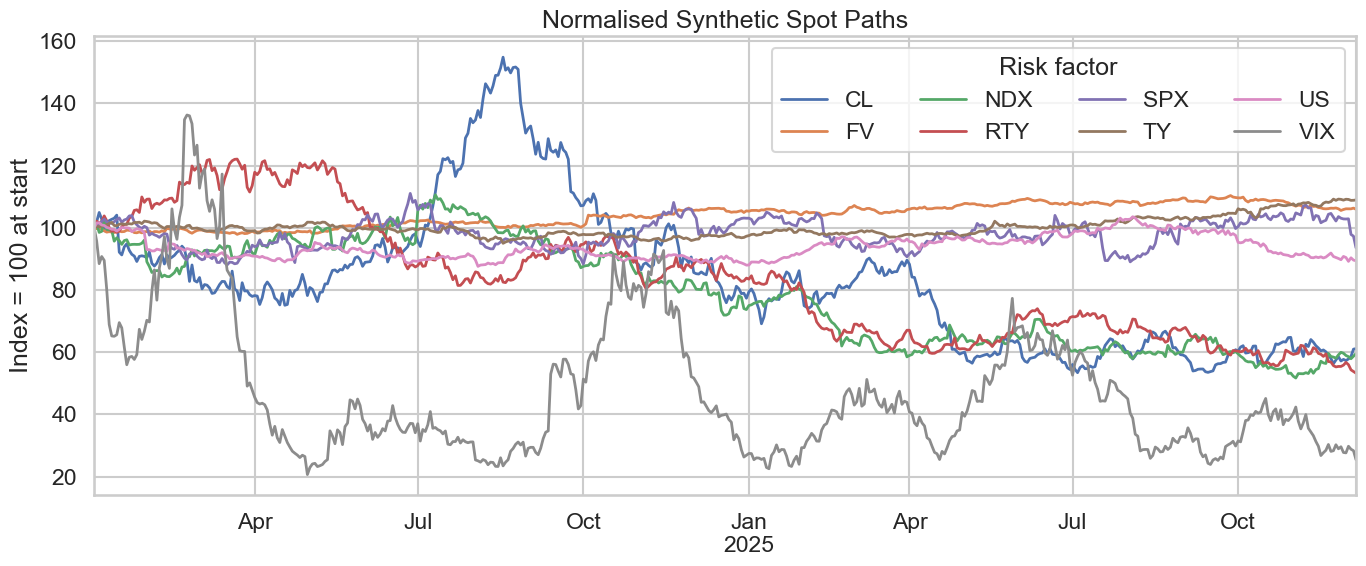

In [5]:
spot_panel = market_data.pivot(index="date", columns="risk_factor_id", values="spot").sort_index()
normalized_spots = spot_panel.div(spot_panel.iloc[0]).mul(100)

fig, ax = plt.subplots(figsize=(14, 6))
normalized_spots.plot(ax=ax, linewidth=2)
ax.set_title("Normalised Synthetic Spot Paths")
ax.set_ylabel("Index = 100 at start")
ax.set_xlabel("")
ax.legend(title="Risk factor", ncol=4, frameon=True)
plt.tight_layout()
plt.show()


## 3. Portfolio Construction and Collateral

Positions are generated by member style and then allowed to drift day by day. Collateral is posted as cash plus government bonds after haircut. This creates a realistic adequacy question: members can have large directional exposure, heterogeneous liquidity, and collateral that is only loosely proportional to gross exposure.

,member_id,instruments_held,net_market_value,gross_market_value,gross_delta_equiv,gross_vega_equiv,collateral_value_post_haircut,member_type,governance_tier,liquidity_multiplier
5,MBR_006,3,"-544,802,912.16","555,347,719.56","1,309,900.00","5,500,753.16","34,411,007.02",concentrated_vol,tier_2,1.30
4,MBR_005,5,"-63,587,357.05","337,543,056.45","1,258,220.00",0.00,"20,270,545.64",relative_value,tier_2,0.80
3,MBR_004,5,"-26,083,849.09","326,827,483.73","1,422,770.00",0.00,"18,585,703.92",relative_value,tier_2,0.80
8,MBR_009,4,"246,614,609.53","246,614,609.53","1,458,620.00","1,179,612.02","11,058,730.22",weak_liquidity,tier_1,1.50
9,MBR_010,3,"122,589,555.74","122,589,555.74","735,850.00",0.00,"7,430,426.00",directional_macro,tier_2,1.00
0,MBR_001,3,"115,368,058.94","115,368,058.94","560,550.00",0.00,"6,894,266.38",directional_macro,tier_2,1.00
7,MBR_008,6,"25,415,677.62","103,317,111.38","334,130.00",0.00,"6,723,448.59",diversified,tier_2,0.70
6,MBR_007,6,"78,395,983.43","95,784,397.61","409,450.00",0.00,"6,987,060.86",diversified,tier_2,0.70
2,MBR_003,3,"81,690,861.46","81,690,861.46","539,450.00",0.00,"4,950,792.62",directional_macro,tier_2,1.00
1,MBR_002,3,"28,637,834.08","28,637,834.08","202,400.00",0.00,"1,736,881.40",directional_macro,tier_2,1.00


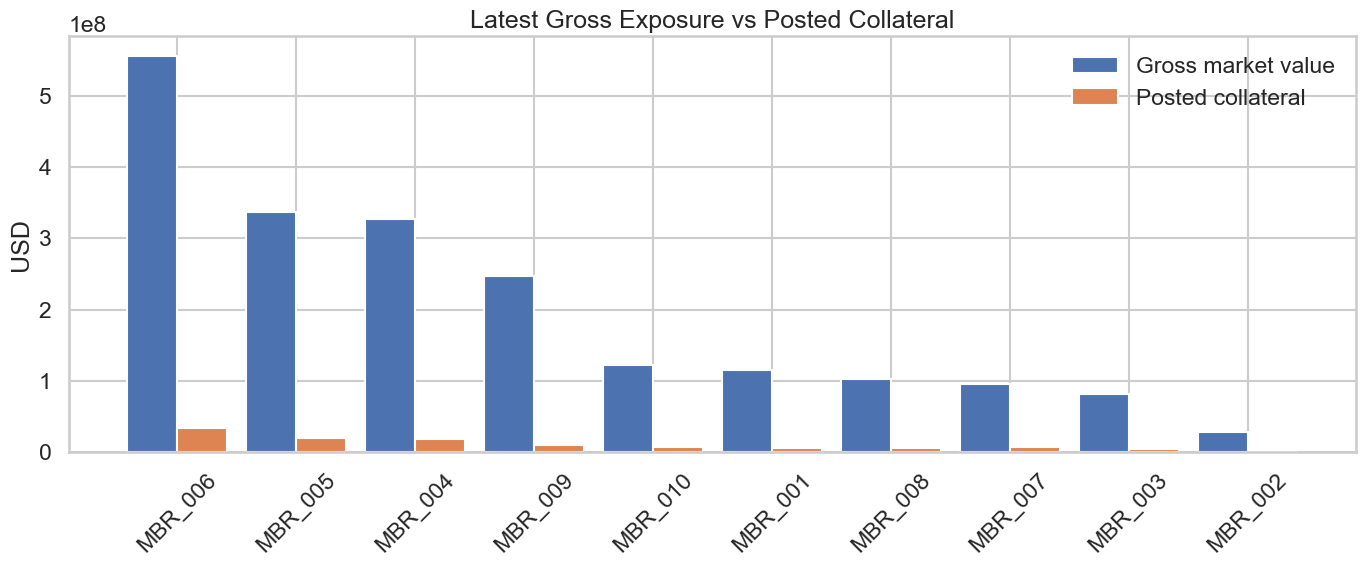

In [6]:
latest_positions = positions[positions["date"] == latest_date].copy()
latest_collateral = collateral[collateral["date"] == latest_date].copy()

member_view = (
    latest_positions.groupby("member_id")
    .agg(
        instruments_held=("instrument_id", "nunique"),
        net_market_value=("market_value", "sum"),
        gross_market_value=("market_value", lambda s: s.abs().sum()),
        gross_delta_equiv=("delta_equiv", lambda s: s.abs().sum()),
        gross_vega_equiv=("vega_equiv", lambda s: s.abs().sum()),
    )
    .reset_index()
    .merge(
        latest_collateral[["member_id", "collateral_value_post_haircut"]],
        on="member_id",
        how="left",
    )
    .merge(
        members[["member_id", "member_type", "governance_tier", "liquidity_multiplier"]],
        on="member_id",
        how="left",
    )
    .sort_values("gross_market_value", ascending=False)
)
display(member_view)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(member_view))
width = 0.42
ax.bar(x - width / 2, member_view["gross_market_value"], width=width, label="Gross market value")
ax.bar(x + width / 2, member_view["collateral_value_post_haircut"], width=width, label="Posted collateral")
ax.set_xticks(x)
ax.set_xticklabels(member_view["member_id"], rotation=45)
ax.set_title("Latest Gross Exposure vs Posted Collateral")
ax.set_ylabel("USD")
ax.legend()
plt.tight_layout()
plt.show()


## 4. Pricing and Scenario Engine

Pricing is intentionally simple but defensible:

- futures are revalued linearly from the underlying spot and contract multiplier
- listed options are revalued with Black-Scholes under the latest realised volatility
- historical simulation uses the last 500 business days of return vectors
- stressed VaR uses the 60-day contiguous window with the highest realised SPX volatility

That last point matters because it prevents margins from collapsing in calm regimes just because the most recent realised volatility is low.

,spot,vol,per_contract_pv
0,4600,0.18,"7,434.65"
1,4800,0.18,"15,144.03"
2,5000,0.18,"26,476.58"
3,5200,0.18,"41,051.17"


Historical scenario matrix: 500 dates x 8 factors
Stressed window: 2024-01-02 to 2024-01-02 (1 business days)


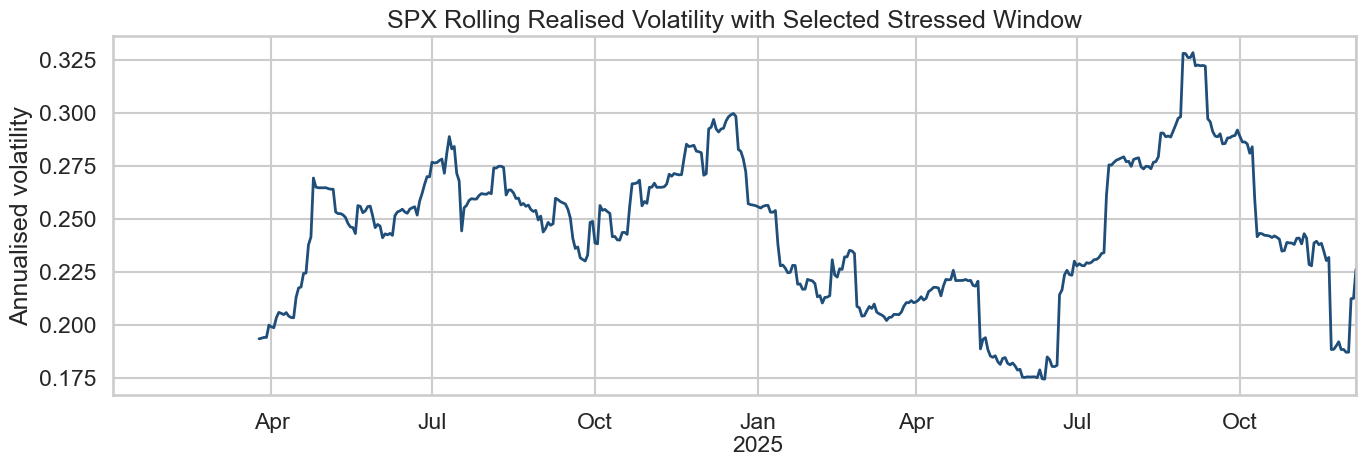

In [7]:
spx_call = instruments.loc[instruments["instrument_id"] == "SPX_C4900"].iloc[0]
pricing_demo = pd.DataFrame(
    {
        "spot": [4600, 4800, 5000, 5200],
        "vol": [0.18, 0.18, 0.18, 0.18],
    }
)
pricing_demo["per_contract_pv"] = pricing_demo.apply(
    lambda row: price_instrument(spx_call, row["spot"], row["vol"]),
    axis=1,
)
display(pricing_demo)

returns_matrix = historical_return_scenarios(market_data)
stressed_matrix = stressed_return_scenarios(market_data)

spx_returns = (
    market_data.loc[market_data["risk_factor_id"] == "SPX", ["date", "return_1d"]]
    .drop_duplicates()
    .sort_values("date")
    .set_index("date")["return_1d"]
)
spx_rolling_vol = spx_returns.rolling(config.STRESSED_WINDOW).std() * np.sqrt(252)

print(f"Historical scenario matrix: {returns_matrix.shape[0]} dates x {returns_matrix.shape[1]} factors")
print(
    "Stressed window: "
    f"{stressed_matrix.index.min().date()} to {stressed_matrix.index.max().date()} "
    f"({len(stressed_matrix)} business days)"
)

fig, ax = plt.subplots(figsize=(14, 5))
spx_rolling_vol.plot(ax=ax, color="#1f4e79", linewidth=2)
ax.axvspan(stressed_matrix.index.min(), stressed_matrix.index.max(), color="#f28e2b", alpha=0.25)
ax.set_title("SPX Rolling Realised Volatility with Selected Stressed Window")
ax.set_ylabel("Annualised volatility")
ax.set_xlabel("")
plt.tight_layout()
plt.show()


## 5. Margin Methodology

The core loss measure is:

$$
\text{liquidation-adjusted loss}
=
\max(\text{HSVaR}_{99}, \text{Stressed VaR}_{99})
+ \text{liquidity add-on}
+ \text{concentration add-on}
$$

Interpretation:

- `HSVaR_99` captures normal historical loss distribution over the last 500 days
- `Stressed VaR_99` anchors the model to a high-vol regime
- the liquidity add-on captures spread crossing, market impact, and liquidation horizon scaling
- the concentration add-on penalises positions that are too large relative to ADV

This is deliberately framed as a liquidation problem, not just a mark-to-market problem.

,member_id,hsvar_99,stressed_var_99,liquidity_addon,concentration_addon,liquidation_adjusted_loss,required_margin
33,MBR_004,"18,849,372.40","18,849,372.40","1,221,720.71",0.00,"20,071,093.11","20,071,093.11"
34,MBR_005,"17,218,394.46","17,218,394.46","1,377,932.95",0.00,"18,596,327.41","18,596,327.41"
38,MBR_009,"14,398,546.24","14,398,546.24","3,418,110.17",0.00,"17,816,656.41","17,816,656.41"
35,MBR_006,"8,668,511.56","8,668,511.56","3,706,377.63",0.00,"12,374,889.19","12,374,889.19"
39,MBR_010,"8,476,282.91","8,476,282.91","428,022.99",0.00,"8,904,305.90","8,904,305.90"
30,MBR_001,"6,959,255.27","6,959,255.27","378,343.12",0.00,"7,337,598.39","7,337,598.39"
32,MBR_003,"6,430,549.42","6,430,549.42","275,505.70",0.00,"6,706,055.12","6,706,055.12"
36,MBR_007,"6,368,261.07","6,368,261.07","210,478.80",0.00,"6,578,739.87","6,578,739.87"
37,MBR_008,"5,686,530.76","5,686,530.76","216,918.03",0.00,"5,903,448.79","5,903,448.79"
31,MBR_002,"1,872,233.74","1,872,233.74","53,220.75",0.00,"1,925,454.49","1,925,454.49"


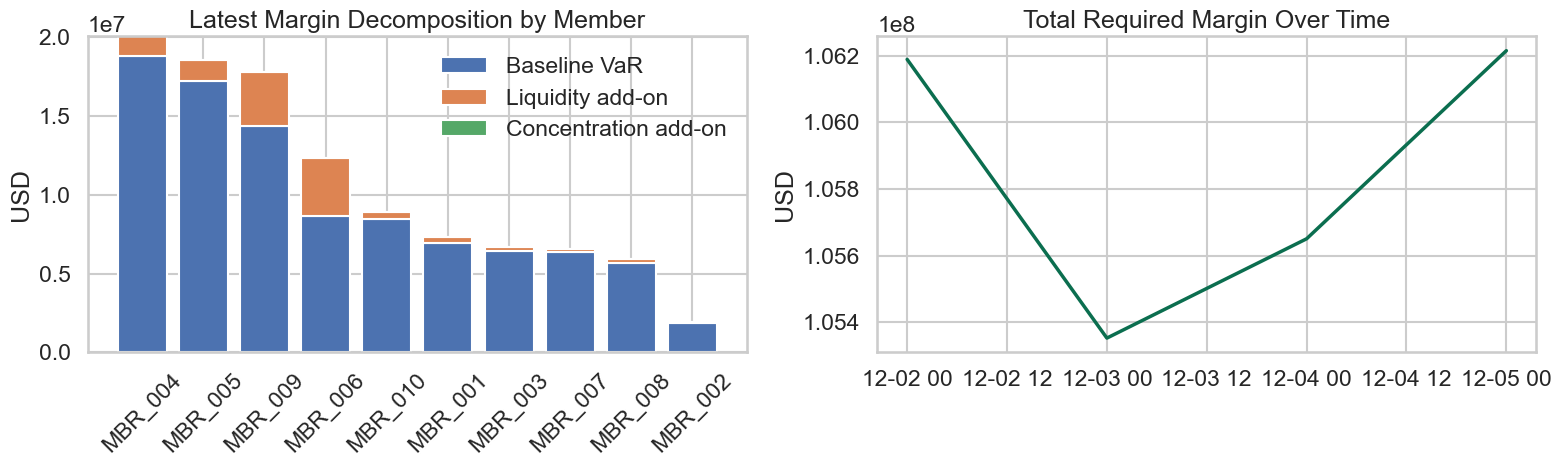

In [8]:
latest_margin = margins[margins["date"] == latest_date].copy().sort_values("required_margin", ascending=False)
display(
    latest_margin[
        [
            "member_id",
            "hsvar_99",
            "stressed_var_99",
            "liquidity_addon",
            "concentration_addon",
            "liquidation_adjusted_loss",
            "required_margin",
        ]
    ]
)

margin_trend = margins.groupby("date")["required_margin"].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(latest_margin["member_id"], latest_margin["hsvar_99"], label="Baseline VaR")
axes[0].bar(
    latest_margin["member_id"],
    latest_margin["liquidity_addon"],
    bottom=latest_margin["hsvar_99"],
    label="Liquidity add-on",
)
axes[0].bar(
    latest_margin["member_id"],
    latest_margin["concentration_addon"],
    bottom=latest_margin["hsvar_99"] + latest_margin["liquidity_addon"],
    label="Concentration add-on",
)
axes[0].set_title("Latest Margin Decomposition by Member")
axes[0].set_ylabel("USD")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

axes[1].plot(margin_trend["date"], margin_trend["required_margin"], color="#0b6e4f", linewidth=2.5)
axes[1].set_title("Total Required Margin Over Time")
axes[1].set_ylabel("USD")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()


## 6. Adequacy Controls and Margin Calls

Required margin by itself is not enough. The controls layer converts model output into operational actions.

- `coverage_ratio = posted_margin / required_margin`
- `green` if coverage is at least 1.10
- `amber` if coverage is at least 1.00 but below 1.10
- `red` if coverage is below 1.00
- margin calls only trigger when the shortfall exceeds both the threshold and the minimum transfer amount

That is the bridge between quantitative risk and actual collateral operations.

,Metric,Value
0,Latest date,2025-12-05
1,Aggregate coverage,1.12
2,Red members,6
3,Amber members,2
4,Green members,2
5,Triggered margin calls,6
6,Margin call amount,"12,104,362.88"


,member_id,posted_margin,required_margin,coverage_ratio,traffic_light,margin_call,threshold_breached,mta_triggered
38,MBR_009,"11,058,730.22","17,816,656.41",0.62,red,"6,757,926.19",True,True
32,MBR_003,"4,950,792.62","6,706,055.12",0.74,red,"1,755,262.50",True,True
39,MBR_010,"7,430,426.00","8,904,305.90",0.83,red,"1,473,879.90",True,True
31,MBR_002,"1,736,881.40","1,925,454.49",0.90,red,"188,573.09",True,True
33,MBR_004,"18,585,703.92","20,071,093.11",0.93,red,"1,485,389.19",True,True
30,MBR_001,"6,894,266.38","7,337,598.39",0.94,red,"443,332.01",True,True
36,MBR_007,"6,987,060.86","6,578,739.87",1.06,amber,0.00,False,False
34,MBR_005,"20,270,545.64","18,596,327.41",1.09,amber,0.00,False,False
37,MBR_008,"6,723,448.59","5,903,448.79",1.14,green,0.00,False,False
35,MBR_006,"34,411,007.02","12,374,889.19",2.78,green,0.00,False,False


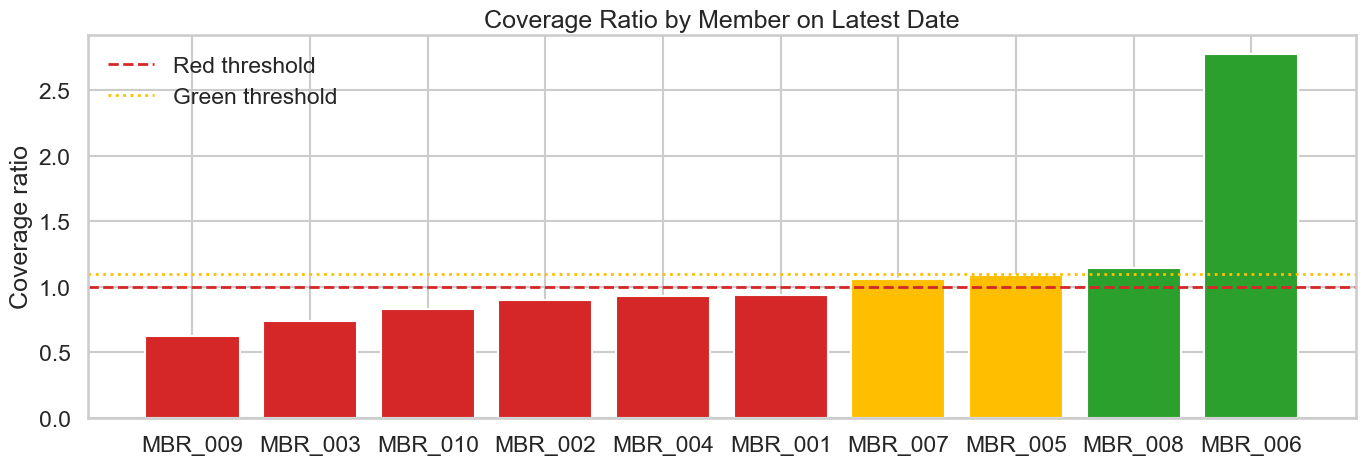

In [9]:
latest_adequacy = adequacy[adequacy["date"] == latest_date].copy().sort_values("coverage_ratio")

traffic_order = ["red", "amber", "green"]
traffic_counts = (
    latest_adequacy["traffic_light"].value_counts().reindex(traffic_order).fillna(0).astype(int)
)
adequacy_summary = pd.DataFrame(
    [
        ("Latest date", latest_date_str),
        ("Aggregate coverage", latest_adequacy["posted_margin"].sum() / latest_adequacy["required_margin"].sum()),
        ("Red members", traffic_counts["red"]),
        ("Amber members", traffic_counts["amber"]),
        ("Green members", traffic_counts["green"]),
        ("Triggered margin calls", int((latest_adequacy["margin_call"] > 0).sum())),
        ("Margin call amount", latest_adequacy["margin_call"].sum()),
    ],
    columns=["Metric", "Value"],
)
display(adequacy_summary)

display(
    latest_adequacy[
        [
            "member_id",
            "posted_margin",
            "required_margin",
            "coverage_ratio",
            "traffic_light",
            "margin_call",
            "threshold_breached",
            "mta_triggered",
        ]
    ]
)

color_map = {"green": "#2ca02c", "amber": "#ffbf00", "red": "#d62728"}
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(
    latest_adequacy["member_id"],
    latest_adequacy["coverage_ratio"],
    color=latest_adequacy["traffic_light"].map(color_map).fillna("#7f7f7f"),
)
ax.axhline(1.00, color="#d62728", linestyle="--", linewidth=2, label="Red threshold")
ax.axhline(1.10, color="#ffbf00", linestyle=":", linewidth=2, label="Green threshold")
ax.set_title("Coverage Ratio by Member on Latest Date")
ax.set_ylabel("Coverage ratio")
ax.set_xlabel("")
ax.legend()
plt.tight_layout()
plt.show()


## 7. Backtesting and Model Controls

The backtesting layer asks a simple governance question: did realised losses exceed prior-day margin? That creates exception tracking, rolling counts, and methodology-review triggers.

Separately, the DQ layer monitors stale data, extreme returns, implausible volatilities, missing data, and exposure jumps. A real risk engine needs both model-performance evidence and operational-quality evidence.

,Metric,Value
0,Backtesting observations,30.00
1,Exceptions,1.00
2,Exception rate,0.03
3,Max rolling exceptions,1.00
4,Members with any exception,1.00


,issue,count
0,exposure_jump,236
1,outlier_return,25


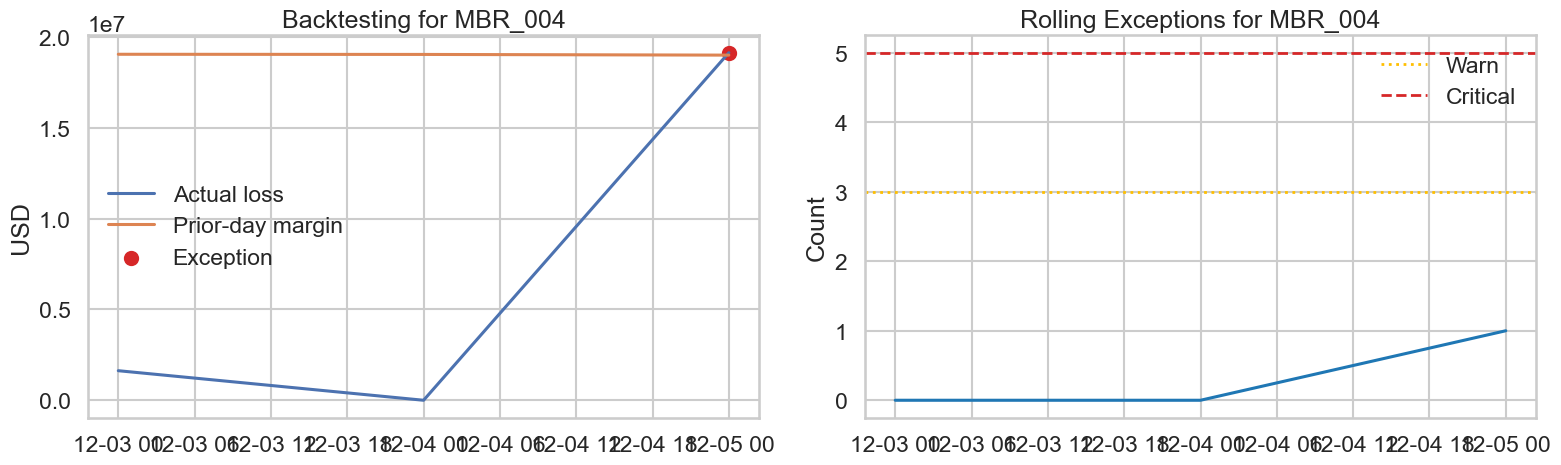

,date,member_id,pnl_1d,prior_margin,actual_loss,is_exception
0,2025-12-05,MBR_004,"-19,133,899.26","19,001,210.98","19,133,899.26",True


In [10]:
exception_rows = exceptions[exceptions["is_exception"]].copy()
focus_member = (
    exception_rows.sort_values("actual_loss", ascending=False)["member_id"].iloc[0]
    if not exception_rows.empty
    else exceptions["member_id"].iloc[0]
)

exception_summary = pd.DataFrame(
    [
        ("Backtesting observations", len(exceptions)),
        ("Exceptions", int(exceptions["is_exception"].sum())),
        ("Exception rate", exceptions["is_exception"].mean()),
        ("Max rolling exceptions", rolling_exceptions["rolling_exceptions"].max()),
        ("Members with any exception", exception_rows["member_id"].nunique()),
    ],
    columns=["Metric", "Value"],
)
display(exception_summary)

dq_issue_counts = (
    dq_flags["issue"].value_counts().rename_axis("issue").reset_index(name="count")
    if not dq_flags.empty and "issue" in dq_flags.columns
    else pd.DataFrame(columns=["issue", "count"])
)
display(dq_issue_counts if not dq_issue_counts.empty else pd.DataFrame({"message": ["No DQ issues flagged"]}))

member_bt = exceptions[exceptions["member_id"] == focus_member].sort_values("date")
member_roll = rolling_exceptions[rolling_exceptions["member_id"] == focus_member].sort_values("date")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(member_bt["date"], member_bt["actual_loss"], label="Actual loss", linewidth=2.2)
axes[0].plot(member_bt["date"], member_bt["prior_margin"], label="Prior-day margin", linewidth=2.2)
if member_bt["is_exception"].any():
    exc_points = member_bt[member_bt["is_exception"]]
    axes[0].scatter(exc_points["date"], exc_points["actual_loss"], color="#d62728", s=90, label="Exception")
axes[0].set_title(f"Backtesting for {focus_member}")
axes[0].set_ylabel("USD")
axes[0].legend()

axes[1].plot(member_roll["date"], member_roll["rolling_exceptions"], color="#1f77b4", linewidth=2.2)
axes[1].axhline(config.BACKTEST_EXCEPTION_WARN, color="#ffbf00", linestyle=":", linewidth=2, label="Warn")
axes[1].axhline(config.BACKTEST_EXCEPTION_CRITICAL, color="#d62728", linestyle="--", linewidth=2, label="Critical")
axes[1].set_title(f"Rolling Exceptions for {focus_member}")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

display(exception_rows.sort_values("actual_loss", ascending=False).reset_index(drop=True))


## 8. Governance, Escalation, and Reporting

The escalation engine converts signals into actions with explicit ownership.

Typical triggers include:

- a red adequacy breach
- consecutive red days
- a material margin call
- concentration add-ons above the watchlist threshold
- stale-data conditions that require a provisional run

The reporting layer then packages those outcomes into daily review notes, breach registers, weekly exception summaries, and monthly committee packs.

In [11]:
escalation_summary = (
    escalation_log.groupby(["rule_id", "owner", "severity"])
    .size()
    .reset_index(name="count")
    .sort_values(["count", "rule_id"], ascending=[False, True])
)
display(escalation_summary)

latest_member_adequacy = export_member_margin_adequacy(latest_date, adequacy)
latest_breach_register = generate_breach_register(latest_date, adequacy, exceptions, dq_flags, escalation_log)
display(latest_member_adequacy)
display(latest_breach_register)

committee_pack = monthly_committee_pack(
    latest_date,
    adequacy,
    exceptions,
    dq_flags,
    escalation_log,
    members,
)
daily_review_text = daily_risk_review(latest_date, adequacy, exceptions, dq_flags, escalation_log)
committee_pack_text = committee_pack_markdown(committee_pack)

display(Markdown("### Daily Risk Review Excerpt"))
display(Markdown("\n".join(daily_review_text.splitlines()[:30])))

display(Markdown("### Committee Pack Excerpt"))
display(Markdown("\n".join(committee_pack_text.splitlines()[:24])))

report_inventory = pd.DataFrame(
    [
        ("Daily review memo", "reports/daily/daily_risk_review_*.md"),
        ("Daily adequacy export", "reports/daily/member_margin_adequacy_*.csv"),
        ("Daily breach register", "reports/daily/breach_register_*.csv"),
        ("Weekly exception report", "reports/weekly/weekly_*.md"),
        ("Monthly committee pack", "reports/committee_pack/committee_pack_*.md"),
        ("Interactive dashboard", "app/streamlit_app.py"),
    ],
    columns=["Artifact", "Location"],
)
display(report_inventory)


,rule_id,owner,severity,count
0,ESC-001,Risk Analyst,medium,23
2,ESC-006,Margin Operations,high,20
1,ESC-002,Senior Risk Officer,high,6


,date,member_id,posted_margin,required_margin,coverage_ratio,traffic_light,margin_call,threshold_breached,mta_triggered,hsvar_99,stressed_var_99,liquidity_addon,concentration_addon,liquidation_adjusted_loss
30,2025-12-05,MBR_001,"6,894,266.38","7,337,598.39",0.94,red,"443,332.01",True,True,"6,959,255.27","6,959,255.27","378,343.12",0.00,"7,337,598.39"
31,2025-12-05,MBR_002,"1,736,881.40","1,925,454.49",0.90,red,"188,573.09",True,True,"1,872,233.74","1,872,233.74","53,220.75",0.00,"1,925,454.49"
32,2025-12-05,MBR_003,"4,950,792.62","6,706,055.12",0.74,red,"1,755,262.50",True,True,"6,430,549.42","6,430,549.42","275,505.70",0.00,"6,706,055.12"
33,2025-12-05,MBR_004,"18,585,703.92","20,071,093.11",0.93,red,"1,485,389.19",True,True,"18,849,372.40","18,849,372.40","1,221,720.71",0.00,"20,071,093.11"
34,2025-12-05,MBR_005,"20,270,545.64","18,596,327.41",1.09,amber,0.00,False,False,"17,218,394.46","17,218,394.46","1,377,932.95",0.00,"18,596,327.41"
35,2025-12-05,MBR_006,"34,411,007.02","12,374,889.19",2.78,green,0.00,False,False,"8,668,511.56","8,668,511.56","3,706,377.63",0.00,"12,374,889.19"
36,2025-12-05,MBR_007,"6,987,060.86","6,578,739.87",1.06,amber,0.00,False,False,"6,368,261.07","6,368,261.07","210,478.80",0.00,"6,578,739.87"
37,2025-12-05,MBR_008,"6,723,448.59","5,903,448.79",1.14,green,0.00,False,False,"5,686,530.76","5,686,530.76","216,918.03",0.00,"5,903,448.79"
38,2025-12-05,MBR_009,"11,058,730.22","17,816,656.41",0.62,red,"6,757,926.19",True,True,"14,398,546.24","14,398,546.24","3,418,110.17",0.00,"17,816,656.41"
39,2025-12-05,MBR_010,"7,430,426.00","8,904,305.90",0.83,red,"1,473,879.90",True,True,"8,476,282.91","8,476,282.91","428,022.99",0.00,"8,904,305.90"


,breach_id,date,member_id,breach_type,severity,description,owner,status,escalation_level,target_resolution_date
0,BRX-20251205-0001,2025-12-05,MBR_001,margin_insufficiency,high,Coverage ratio 94.00% below 1.00 threshold,Clearing Risk,open,senior_review,2025-12-06
1,BRX-20251205-0002,2025-12-05,MBR_002,margin_insufficiency,high,Coverage ratio 90.00% below 1.00 threshold,Clearing Risk,open,senior_review,2025-12-06
2,BRX-20251205-0003,2025-12-05,MBR_003,margin_insufficiency,high,Coverage ratio 74.00% below 1.00 threshold,Clearing Risk,open,senior_review,2025-12-06
3,BRX-20251205-0004,2025-12-05,MBR_004,margin_insufficiency,high,Coverage ratio 93.00% below 1.00 threshold,Clearing Risk,open,senior_review,2025-12-06
4,BRX-20251205-0005,2025-12-05,MBR_009,margin_insufficiency,high,Coverage ratio 62.00% below 1.00 threshold,Clearing Risk,open,senior_review,2025-12-06
5,BRX-20251205-0006,2025-12-05,MBR_010,margin_insufficiency,high,Coverage ratio 83.00% below 1.00 threshold,Clearing Risk,open,senior_review,2025-12-06
6,BRX-20251205-0007,2025-12-05,MBR_004,backtesting_exception,medium,"Actual loss $19,133,899 exceeded prior-day mar...",Risk Methodology,open,analyst_review,2025-12-08
7,BRX-20251205-0008,2025-12-05,MBR_004,model_control,medium,exposure_jump: nan,Quant Risk,open,analyst_review,2025-12-07


### Daily Risk Review Excerpt

# Daily Risk Review – 2025-12-05

---

## 1. Top 5 Weakest Members by Coverage

| Member | Coverage | Traffic Light | Required Margin | Posted Margin | Margin Call |
|--------|----------|---------------|-----------------|---------------|-------------|
| MBR_009 | 62.00% | RED | 17,816,656 | 11,058,730 | 6,757,926 |
| MBR_003 | 74.00% | RED | 6,706,055 | 4,950,793 | 1,755,262 |
| MBR_010 | 83.00% | RED | 8,904,306 | 7,430,426 | 1,473,880 |
| MBR_002 | 90.00% | RED | 1,925,454 | 1,736,881 | 188,573 |
| MBR_004 | 93.00% | RED | 20,071,093 | 18,585,704 | 1,485,389 |

## 2. New Red / Amber Breaches

- **Red:** 6 members
- **Amber:** 2 members
  - MBR_001: coverage 94.00%
  - MBR_002: coverage 90.00%
  - MBR_003: coverage 74.00%
  - MBR_004: coverage 93.00%
  - MBR_009: coverage 62.00%
  - MBR_010: coverage 83.00%

## 3. Open Data Quality Issues

- exposure_jump: 1 flag(s)

## 4. Backtesting Alerts

### Committee Pack Excerpt

# Monthly Risk Committee Pack
**Period:** 2025-11-05 00:00:00 to 2025-12-05 00:00:00

## 1. Margin Trend
*(See attached chart – total required margin by day)*

## 2. Top Stressed Members
| Member | Type | Avg Coverage | Min Coverage | Red Days |
|--------|------|-------------|-------------|----------|
| MBR_009 | weak_liquidity | 59.75% | 52.00% | 4 |
| MBR_003 | directional_macro | 70.00% | 65.00% | 4 |
| MBR_010 | directional_macro | 85.00% | 82.00% | 4 |
| MBR_001 | directional_macro | 88.00% | 83.00% | 4 |
| MBR_002 | directional_macro | 92.75% | 85.00% | 4 |

## 3. Coverage Ratio Distribution
- Mean: 107.50%
- Std: 0.5489
- Min: 52.00%
- Max: 321.00%

## 4. Backtesting Summary – 1 exceptions
- MBR_004: 1 exceptions
- MBR_001: 0 exceptions

,Artifact,Location
0,Daily review memo,reports/daily/daily_risk_review_*.md
1,Daily adequacy export,reports/daily/member_margin_adequacy_*.csv
2,Daily breach register,reports/daily/breach_register_*.csv
3,Weekly exception report,reports/weekly/weekly_*.md
4,Monthly committee pack,reports/committee_pack/committee_pack_*.md
5,Interactive dashboard,app/streamlit_app.py


## 9. Validation, Limitations, and Next Extensions

The repository already contains automated tests and validation scripts. That matters because a project with governance ambitions should prove not only that it computes numbers, but also that its controls and report outputs are stable.

In [12]:
validation_inventory = pd.DataFrame(
    [
        ("validate.py", "Imports, data files, processed tables, reports, quick sanity checks"),
        ("validate_app.py", "AST and compile validation for the Streamlit app"),
        ("tests/test_pricing.py", "Black-Scholes sanity, parity, delta bounds"),
        ("tests/test_margin.py", "VaR and add-on behaviour"),
        ("tests/test_controls.py", "Coverage ratio, traffic lights, margin calls, controls"),
        ("tests/test_reporting.py", "Daily, weekly, committee, and breach-register outputs"),
    ],
    columns=["Validation Artifact", "What it Covers"],
)
display(validation_inventory)

limitations = pd.DataFrame(
    {
        "Known limitation": [
            "Stylised educational margin methodology, not a production CCP model",
            "Simplified liquidation assumptions and no auction default-management process",
            "Limited product universe and simplified collateral eligibility",
            "No member default probability or credit migration modelling",
            "Static implied-vol treatment for listed options",
            "Scenario design may miss some cross-asset contagion channels",
        ]
    }
)
display(limitations)

RUN_VALIDATION = False
if RUN_VALIDATION:
    subprocess.run([sys.executable, "validate.py"], cwd=PROJECT_ROOT, check=True)
    subprocess.run([sys.executable, "validate_app.py"], cwd=PROJECT_ROOT, check=True)
    subprocess.run([sys.executable, "-m", "pytest", "tests", "-q"], cwd=PROJECT_ROOT, check=True)


,Validation Artifact,What it Covers
0,validate.py,"Imports, data files, processed tables, reports..."
1,validate_app.py,AST and compile validation for the Streamlit app
2,tests/test_pricing.py,"Black-Scholes sanity, parity, delta bounds"
3,tests/test_margin.py,VaR and add-on behaviour
4,tests/test_controls.py,"Coverage ratio, traffic lights, margin calls, ..."
5,tests/test_reporting.py,"Daily, weekly, committee, and breach-register ..."


,Known limitation
0,"Stylised educational margin methodology, not a..."
1,Simplified liquidation assumptions and no auct...
2,Limited product universe and simplified collat...
3,No member default probability or credit migrat...
4,Static implied-vol treatment for listed options
5,Scenario design may miss some cross-asset cont...


## Closing Talk Track

If you need a short close:

1. The project asks a practical CCP question: is posted collateral sufficient after accounting for liquidation reality, not just statistical VaR?
2. The answer is built from a full workflow: synthetic market and portfolio generation, full revaluation, baseline and stressed VaR, liquidity and concentration add-ons, adequacy controls, backtesting, and escalation.
3. The strongest portfolio angle is governance. The engine does not stop at numbers; it produces actionable calls, breach tracking, and committee-facing reporting.
4. The main next step toward production realism would be richer scenario design, more realistic collateral policy, and default-management mechanics.